# Análise Exploratória de Dados - Base Varejo

## Sprint 1: Importação e Reconhecimento da Base

Nesta etapa inicial, realizei a importação do arquivo `Base Varejo.csv` utilizando a biblioteca Pandas. A base foi carregada considerando o ponto e vírgula (`;`) como separador das colunas.

Após a importação, foi realizada uma análise inicial da estrutura dos dados, verificando a quantidade de registros, a quantidade de colunas, os nomes das colunas e os respectivos tipos de dados.

Também foram visualizadas as primeiras linhas da base por meio do método `head()`, com o objetivo de compreender inicialmente a organização e o conteúdo dos dados.

A partir dessa análise inicial, foram identificados pontos de atenção que serão avaliados nas próximas etapas de transformação e limpeza, como a conversão da coluna `DATA` para o formato adequado, a verificação de valores nulos, categorias vazias, duplicidades e possíveis inconsistências nos dados.

In [7]:
# ==========================================
# SPRINT 1: IMPORTAÇÃO E EXPLORAÇÃO INICIAL
# ==========================================

import pandas as pd
import numpy as np

# Carregando a base de dados com o separador correto (ponto e vírgula)
df = pd.read_csv("Base Varejo.csv", sep=";")

# Visualizando as primeiras linhas para entender a estrutura dos dados
print("Primeiras linhas do dataset:")
display(df.head())

# Verificando informações gerais: quantidade de registros, colunas e tipos de dados
print("\nInformações gerais sobre a base de dados:")
df.info()

# Verificando a quantidade de registros e colunas
print(f"Quantidade de registros: {df.shape[0]}")

# Verificando a quantidade de colunas
print(f"Quantidade de colunas: {df.shape[1]}")

# Verificando os nomes das colunas
print("\nColunas:")

# Imprimindo a lista de nomes de colunas
print(df.columns.tolist())


Primeiras linhas do dataset:


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN



Informações gerais sobre a base de dados:
<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  str    
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  str    
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  str    
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  str    
 9   PR_NOME      830000 non-null  str    
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), str(5)
memory usage: 88.7 MB
Quantidade de registros: 830000
Quantidade de colunas: 14

Colunas:
['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'C

## Sprint 2: Transformação e Padronização dos Dados

Nesta etapa, foram realizadas transformações necessárias para melhorar a padronização dos dados antes das análises.

Nas colunas `PR_CAT` e `PR_NOME`, foram utilizados os métodos `str.strip()` e `str.upper()` para remover espaços desnecessários e padronizar os textos em letras maiúsculas.

Também foi realizada a conversão da coluna `DATA` para o formato `datetime`, utilizando o parâmetro `errors='coerce'` para tratar possíveis valores que não possam ser convertidos para uma data válida.

Ao final da etapa, os tipos de dados foram verificados para confirmar as transformações realizadas e preparar a base para as etapas seguintes de limpeza e análise.

In [8]:
# ==========================================
# SPRINT 2: TRANSFORMAÇÃO E PADRONIZAÇÃO
# ==========================================

# Padronização dos textos das colunas de categoria e nome do produto
df['PR_CAT'] = df['PR_CAT'].str.strip().str.upper()
df['PR_NOME'] = df['PR_NOME'].str.strip().str.upper()

# Conversão da coluna DATA para o formato datetime
# Valores que não puderem ser convertidos serão considerados NaT
df['DATA'] = pd.to_datetime(
    df['DATA'],
    format='%d/%m/%Y',
    errors='coerce'
)

print("\n--- TIPOS DE DADOS APÓS A TRANSFORMAÇÃO ---")
print(df.dtypes)


--- TIPOS DE DADOS APÓS A TRANSFORMAÇÃO ---
DATA           datetime64[us]
CO_ID                   int64
CL_ID                   int64
CL_GENERO                 str
CL_EC                   int64
CL_FHL                  int64
CL_SEG                    str
PR_ID                   int64
PR_CAT                    str
PR_NOME                   str
Unnamed: 10           float64
Unnamed: 11           float64
Unnamed: 12           float64
Unnamed: 13           float64
dtype: object


## Sprint 3: Limpeza de Nulos e Duplicatas

Nesta etapa, foram identificados e tratados problemas de qualidade encontrados na base de dados.

Inicialmente, foi realizado um diagnóstico dos valores nulos em cada coluna, da quantidade de registros duplicados e de possíveis inconsistências na coluna `DATA`.

Também foi realizada a validação do identificador `CO_ID`, verificando a existência de registros com identificadores duplicados antes da etapa de limpeza.

As colunas residuais `Unnamed` foram removidas por não apresentarem informações relevantes para a análise. A remoção dessas colunas evita que dados estruturais provenientes da exportação da base sejam considerados nas análises.

Para a coluna `PR_CAT`, foram identificados valores nulos ou vazios e aplicado um tratamento utilizando uma estrutura condicional `if/else`. Esses valores foram padronizados como `Sem Categoria`.

Por fim, os registros completamente duplicados foram removidos utilizando o método `drop_duplicates()`, contribuindo para a qualidade e consistência da base para as etapas seguintes da análise.
A validação do `CO_ID` apresentou grande quantidade de identificadores repetidos. Entretanto, essa repetição não foi considerada uma duplicidade de registro, pois uma mesma compra pode apresentar diferentes produtos associados ao mesmo identificador. Por isso, foram removidos somente os registros completamente duplicados.

In [9]:
# ==========================================
# SPRINT 3: LIMPEZA DE NULOS E DUPLICATAS
# ==========================================

print("\n--- DIAGNÓSTICO DE VALORES NULOS ---")
print(df.isnull().sum())

print("\n--- DIAGNÓSTICO DE DUPLICATAS ---")
print(f"Quantidade de registros duplicados: {df.duplicated().sum()}")

# Verificando possíveis datas que não puderam ser convertidas
print("\n--- DIAGNÓSTICO DA COLUNA DATA ---")
print(f"Datas inválidas ou não convertidas: {df['DATA'].isna().sum()}")

# Validação do identificador de número de compra (CO_ID)
print("\n--- VALIDAÇÃO DO IDENTIFICADOR CO_ID ---")
print(f"Quantidade de CO_ID duplicados: {df['CO_ID'].duplicated().sum()}")

# Tratamento das colunas residuais 'Unnamed'
colunas_vazias = [
    'Unnamed: 10',
    'Unnamed: 11',
    'Unnamed: 12',
    'Unnamed: 13'
]

df = df.drop(
    columns=colunas_vazias,
    errors='ignore'
)

# Tratamento das categorias vazias ou nulas
categorias_ajustadas = []

for item in df['PR_CAT']:
    if pd.isna(item) or item == "" or item == "NAN" or item == "NONE":
        categorias_ajustadas.append("Sem Categoria")
    else:
        categorias_ajustadas.append(item)

df['PR_CAT'] = categorias_ajustadas

# Remoção de registros completamente duplicados
df = df.drop_duplicates()

print("\n--- DIAGNÓSTICO DA BASE APÓS A LIMPEZA ---")
df.info()


--- DIAGNÓSTICO DE VALORES NULOS ---
DATA                0
CO_ID               0
CL_ID               0
CL_GENERO           0
CL_EC               0
CL_FHL              0
CL_SEG              0
PR_ID               0
PR_CAT              0
PR_NOME             0
Unnamed: 10    830000
Unnamed: 11    830000
Unnamed: 12    830000
Unnamed: 13    830000
dtype: int64

--- DIAGNÓSTICO DE DUPLICATAS ---
Quantidade de registros duplicados: 96553

--- DIAGNÓSTICO DA COLUNA DATA ---
Datas inválidas ou não convertidas: 0

--- VALIDAÇÃO DO IDENTIFICADOR CO_ID ---
Quantidade de CO_ID duplicados: 811529

--- DIAGNÓSTICO DA BASE APÓS A LIMPEZA ---
<class 'pandas.DataFrame'>
Index: 733447 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   DATA       733447 non-null  datetime64[us]
 1   CO_ID      733447 non-null  int64         
 2   CL_ID      733447 non-null  int64         
 3   CL_GENERO  733447 non-nul

## Sprint 4: Análise Estatística Descritiva (Número de Filhos)

Nesta etapa, foram calculadas as principais estatísticas descritivas da coluna `CL_FHL`, que representa o número de filhos dos clientes.

Foram calculados a contagem, o valor mínimo, o valor máximo, a média, a mediana, o desvio padrão e a moda.

Também foi criado um gráfico de barras para visualizar a distribuição da quantidade de filhos entre os registros da base e facilitar a interpretação dos resultados.

--- PARÂMETROS ESTATÍSTICOS DA COLUNA FILHOS (CL_FHL) ---
Total de Registros na Coluna FILHOS: 733447
Valor Mínimo Registrado:     0
Valor Máximo Registrado:     4
Média Aritmética:            1.15
Mediana (Tendência Central): 0.0
Desvio Padrão (Dispersão):   1.42
Moda (Valor mais Frequente): 0    0
Name: CL_FHL, dtype: int64

--- VISUALIZAÇÃO DA DISTRIBUIÇÃO COM MATPLOTLIB ---


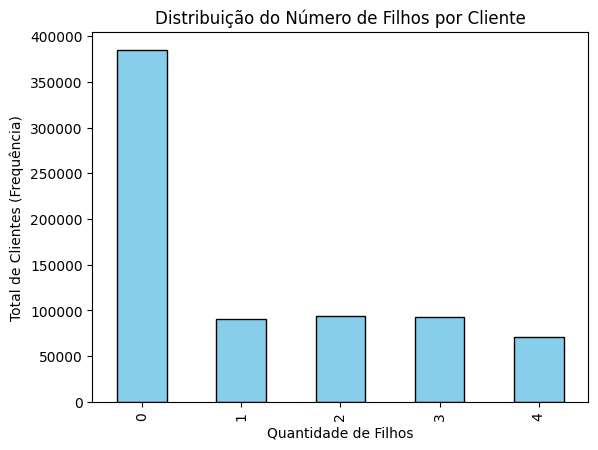

In [6]:
# =====================================================================
# SPRINT 4: GERAÇÃO DE ESTATÍSTICAS BÁSICAS E VISUALIZAÇÃO
# =====================================================================
import matplotlib.pyplot as plt

print("--- PARÂMETROS ESTATÍSTICOS DA COLUNA FILHOS (CL_FHL) ---")

# Calculando os parâmetros estatísticos solicitados
total_filhos = df['CL_FHL'].count()
minimo_filhos   = df['CL_FHL'].min()
maximo_filhos   = df['CL_FHL'].max()
media_filhos    = df['CL_FHL'].mean()
mediana_filhos  = df['CL_FHL'].median()
desvio_filhos   = df['CL_FHL'].std()
moda_filhos     = df['CL_FHL'].mode()

# Exibindo os resultados de forma clara e estruturada
print(f"Total de Registros na Coluna FILHOS: {total_filhos}")
print(f"Valor Mínimo Registrado:     {minimo_filhos}")
print(f"Valor Máximo Registrado:     {maximo_filhos}")
print(f"Média Aritmética:            {media_filhos:.2f}")
print(f"Mediana (Tendência Central): {mediana_filhos}")
print(f"Desvio Padrão (Dispersão):   {desvio_filhos:.2f}")
print(f"Moda (Valor mais Frequente): {moda_filhos}")

print("\n--- VISUALIZAÇÃO DA DISTRIBUIÇÃO COM MATPLOTLIB ---")
# Criando a contagem de valores para o gráfico de barras
df['CL_FHL'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')

# Aplicando os títulos e rótulos usando a biblioteca Matplotlib
plt.title('Distribuição do Número de Filhos por Cliente')
plt.xlabel('Quantidade de Filhos')
plt.ylabel('Total de Clientes (Frequência)')

# Exibindo o gráfico na tela de forma limpa
plt.show()

## Sprint 5: Análise por Agrupamentos e Visualização

Nesta etapa, foram utilizados agrupamentos com `groupby()` para identificar padrões na base de dados.

O primeiro agrupamento apresenta a quantidade de compras distintas por gênero dos clientes. O segundo agrupamento apresenta a quantidade de registros de produtos por categoria.

Para facilitar a interpretação dos resultados, foram criados gráficos de barras para representar visualmente os dois agrupamentos.

Os resultados obtidos também serão utilizados para elaborar as principais conclusões da análise.


--- COMPRAS DISTINTAS POR GÊNERO ---
CL_GENERO
F    9615
M    8856
Name: CO_ID, dtype: int64


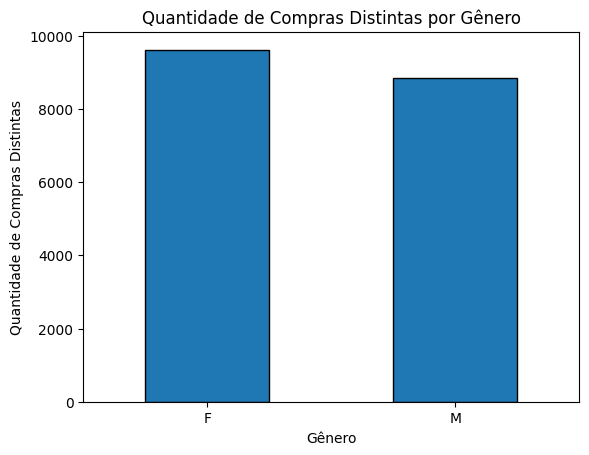


--- QUANTIDADE DE PRODUTOS POR CATEGORIA ---
PR_CAT
ALIMENTOS     384197
HIGIENE       137702
LIMPEZA       128632
BEBIDAS        38264
PET            28553
ACESSORIOS     12871
#N/D            3228
Name: PR_ID, dtype: int64


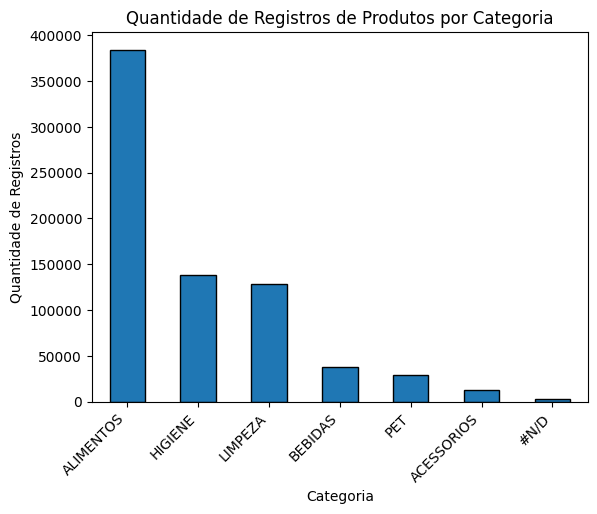

In [11]:
# ==========================================
# SPRINT 5: ANÁLISE POR AGRUPAMENTOS
# ==========================================

# Agrupamento 1: quantidade de compras distintas por gênero
compras_por_genero = (df.groupby('CL_GENERO')['CO_ID'].nunique().sort_values(ascending=False))

print("\n--- COMPRAS DISTINTAS POR GÊNERO ---")
print(compras_por_genero)


# Visualização das compras distintas por gênero
compras_por_genero.plot(kind='bar',edgecolor='black')

plt.title('Quantidade de Compras Distintas por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Compras Distintas')
plt.xticks(rotation=0)
plt.show()


# Agrupamento 2: quantidade de registros de produtos por categoria
produtos_por_categoria = (df.groupby('PR_CAT')['PR_ID'].count().sort_values(ascending=False))

print("\n--- QUANTIDADE DE PRODUTOS POR CATEGORIA ---")
print(produtos_por_categoria)


# Visualização da quantidade de registros por categoria
produtos_por_categoria.plot(kind='bar',edgecolor='black')

plt.title('Quantidade de Registros de Produtos por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Quantidade de Registros')
plt.xticks(rotation=45, ha='right')
plt.show()

## Sprint 6: Preparação da Base Limpa e Versionamento

Nesta etapa final, a base tratada foi preparada para ser utilizada em análises posteriores. Após as etapas de transformação, limpeza e análise, foi gerado um novo arquivo contendo os dados tratados.

Também foram organizados os arquivos do projeto para envio ao repositório público no GitHub, incluindo o notebook com a solução, a base limpa e os arquivos de documentação solicitados.

In [12]:
# ==========================================
# SPRINT 6: EXPORTAÇÃO DA BASE LIMPA
# ==========================================

# Salvando a base após as etapas de limpeza e transformação
df.to_csv("df_limpo.csv", sep=";", index=False)

print("\n--- BASE LIMPA EXPORTADA ---")
print("Arquivo 'df_limpo.csv' criado com sucesso.")
print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")


--- BASE LIMPA EXPORTADA ---
Arquivo 'df_limpo.csv' criado com sucesso.
Quantidade de registros: 733447
Quantidade de colunas: 10
